# 3장 1강: 편향-분산 트레이드오프와 과적합/과소적합 진단

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 모델 복잡도와 과적합/과소적합의 관계를 확인합니다.

- 모델이 너무 단순할 때 나타나는 **고편향(과소적합)** 상태를 확인합니다.
- 모델이 너무 복잡할 때 나타나는 **고분산(과적합)** 상태를 확인합니다.
- `learning_curve()`를 이용하여 학습곡선을 확인합니다.
- `validation_curve()`를 이용하여 모델 복잡도에 따른 Train / Validation 성능 변화를 확인합니다.
- `train-valid gap`을 이용하여 모델 상태를 진단합니다.
- 진단 결과에 맞는 대응 전략을 선택합니다.

> 이 실습에서는 3장 1강 교안에서 다룬 편향-분산, 학습곡선, 검증곡선, train-valid gap, 과적합/과소적합 대응 전략만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- numpy
- matplotlib
- scikit-learn
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택의 여러 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

이번 강의의 목적은 예측 성능 자체를 최대화하는 것이 아니라 **모델 복잡도에 따라 Train / Validation 성능이 어떻게 달라지는지 진단하는 것**입니다.

### 사용할 특성

결측치 처리 자체가 이번 강의의 학습 목표가 아니므로, 결측치가 없는 숫자형 특성 중 일부만 사용합니다.

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `TotalBsmtSF`
- `1stFlrSF`
- `YearBuilt`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 특성과 예측 대상을 선택합니다.
3. 결측치가 없는지 확인합니다.
4. 데이터 크기와 기초 통계량을 확인합니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import learning_curve, validation_curve

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt"
]

X = house[features]
y = house["SalePrice"]

print("X 크기:", X.shape)
print("y 크기:", y.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

print("\n[기초 통계량]")
display(X.describe())

X 크기: (1460, 6)
y 크기: (1460,)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
TotalBsmtSF,0
1stFlrSF,0
YearBuilt,0



[기초 통계량]


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,YearBuilt
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,1057.429452,1162.626712,1971.267808
std,1.382997,525.480383,0.747315,438.705324,386.587738,30.202904
min,1.000000,334.000000,0.000000,0.000000,334.000000,1872.000000
25%,5.000000,1129.500000,1.000000,795.750000,882.000000,1954.000000
50%,6.000000,1464.000000,2.000000,991.500000,1087.000000,1973.000000
75%,7.000000,1776.750000,2.000000,1298.250000,1391.250000,2000.000000
max,10.000000,5642.000000,4.000000,6110.000000,4692.000000,2010.000000


---

# 필수 1. 학습곡선으로 과소적합과 과적합 진단

## 배경

학습곡선은 **학습 데이터의 양을 늘려가며 Train score와 Validation score가 어떻게 변하는지 확인하는 그래프**입니다.

이번 문제에서는 같은 Ames Housing 데이터에 대해 두 개의 결정트리를 비교합니다.

- `max_depth=2` → 복잡도가 낮은 모델
- `max_depth=None` → 깊이를 제한하지 않은 복잡한 모델

## 문제 1. `max_depth=2` 모델의 학습곡선을 그리세요.

### 요구사항

1. `DecisionTreeRegressor(max_depth=2, random_state=42)`를 만듭니다.
2. `learning_curve()`를 사용합니다.
3. `cv=5`를 사용합니다.
4. 학습 데이터 비율은 `np.linspace(0.1, 1.0, 6)`을 사용합니다.
5. 각 구간의 Train score와 Validation score 평균을 계산합니다.
6. 두 점수를 하나의 그래프에 표시합니다.
7. 두 곡선이 어디에서 수렴하는지 확인합니다.

### 확인 포인트

- 두 점수가 모두 낮은 수준에서 가까워지는가?
- 모델이 너무 단순한 상태인지 판단할 수 있는가?

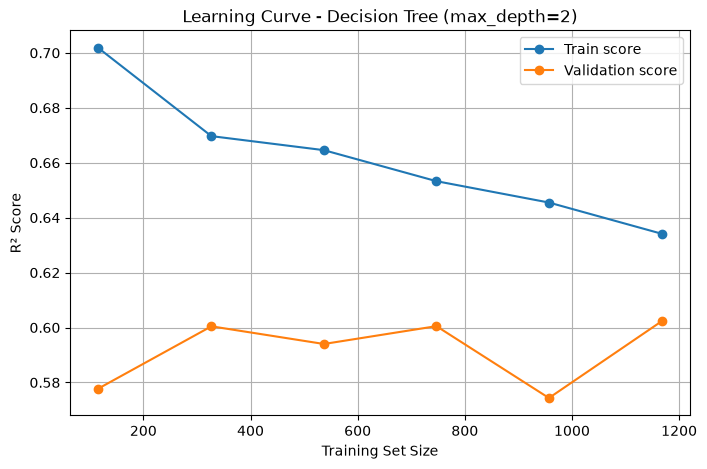

In [2]:
# TODO
# max_depth=2 결정트리의 학습곡선을 그려보세요.

model = DecisionTreeRegressor(max_depth=2, random_state=42)

# 학습 데이터 비율
train_sizes = np.linspace(0.1, 1.0, 6)

# 학습곡선 계산
sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    train_sizes=train_sizes,
    scoring="r2"
)

# 각 구간의 평균 점수 계산
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# 그래프
plt.figure(figsize=(8, 5))

plt.plot(sizes, train_mean, marker="o", label="Train score")
plt.plot(sizes, val_mean, marker="o", label="Validation score")

plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve - Decision Tree (max_depth=2)")
plt.legend()
plt.grid(True)
plt.show()

### Q1. `max_depth=2` 모델은 과소적합과 과적합 중 어느 쪽에 더 가깝다고 볼 수 있나요?

**답변:**  
여기에 작성하세요.

## 문제 2. `max_depth=None` 모델의 학습곡선을 그리세요.

### 요구사항

1. `DecisionTreeRegressor(max_depth=None, random_state=42)`를 만듭니다.
2. 필수 1 문제 1과 동일한 방식으로 `learning_curve()`를 사용합니다.
3. Train score와 Validation score를 그래프로 나타냅니다.
4. 두 곡선 사이의 간격을 확인합니다.

### 확인 포인트

- Train score가 매우 높은가?
- Validation score와의 간격이 크게 유지되는가?
- 고분산(과적합) 신호를 확인할 수 있는가?

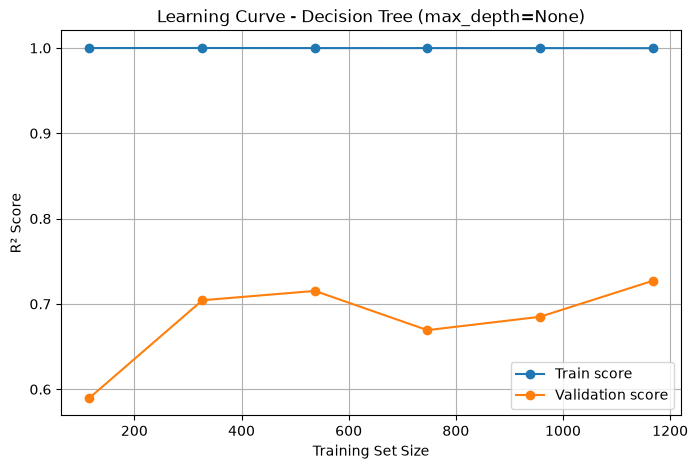

In [3]:
# TODO
# max_depth=None 결정트리의 학습곡선을 그려보세요.

# max_depth=None 결정트리
model = DecisionTreeRegressor(max_depth=None, random_state=42)

# 학습 데이터 비율
train_sizes = np.linspace(0.1, 1.0, 6)

# 학습곡선 계산
sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    train_sizes=train_sizes,
    scoring="r2"
)

# 각 구간의 평균 점수 계산
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# 그래프
plt.figure(figsize=(8, 5))

plt.plot(sizes, train_mean, marker="o", label="Train score")
plt.plot(sizes, val_mean, marker="o", label="Validation score")

plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve - Decision Tree (max_depth=None)")
plt.legend()
plt.grid(True)
plt.show()

### Q2. `max_depth=None` 모델에서 데이터를 더 추가하는 것이 도움이 될 가능성이 있는 이유는 무엇인가요?

**답변:**  
검증점수가 상승 중

---

# 필수 2. 검증곡선과 train-valid gap으로 최적 복잡도 확인

## 배경

검증곡선은 **모델의 하이퍼파라미터를 바꿔가며 Train score와 Validation score의 변화를 확인하는 그래프**입니다.

이번 문제에서는 결정트리의 `max_depth`를 바꾸어 모델 복잡도를 조절합니다.

## 문제 1. `max_depth` 검증곡선을 만드세요.

### 요구사항

1. 다음 `max_depth` 후보를 사용합니다.

```python
param_range = [1, 2, 3, 4, 5, 8, 12, 20, None]
```

2. `validation_curve()`를 사용합니다.
3. `cv=5`를 사용합니다.
4. 각 `max_depth`의 Train score와 Validation score 평균을 계산합니다.
5. `gap = train_mean - valid_mean`을 계산합니다.
6. `max_depth`, `train`, `validation`, `gap`을 DataFrame으로 만듭니다.
7. Train / Validation score를 하나의 그래프에 표시합니다.

### 확인 포인트

- 복잡도가 증가할수록 Train score가 어떻게 변하는가?
- Validation score는 어느 지점까지 좋아지고 이후 어떻게 변하는가?
- train-valid gap은 깊이가 커질수록 어떻게 변하는가?

In [ ]:
# TODO
# validation_curve()를 이용해 max_depth별 Train / Validation score와 gap을 확인하세요.

### Q3. Validation score가 가장 높은 `max_depth`는 무엇인가요?

**답변:**  
여기에 작성하세요.

### Q4. `max_depth`가 매우 커질수록 train-valid gap이 커지는 이유는 무엇인가요?

**답변:**  
여기에 작성하세요.

---

# 과제 1. 모델 상태를 진단하고 대응 전략 선택하기

## 배경

필수 실습에서는 학습곡선과 검증곡선을 이용해 모델의 상태를 확인했습니다.

이번 과제에서는 검증곡선 결과를 이용하여 세 가지 복잡도의 모델 상태를 직접 판단합니다.

> 과제는 필수 실습에서 확인한 결과를 해석하는 수준입니다.

## 문제

다음 세 모델을 확인하세요.

- `max_depth=1`
- `max_depth=8`
- `max_depth=None`

### 요구사항

1. 필수 2에서 만든 `gap_df`에서 세 모델의 Train score, Validation score, gap을 확인합니다.
2. 각 모델을 다음 중 하나로 진단합니다.
   - 과소적합
   - 비교적 적절한 복잡도
   - 과적합
3. 각 모델의 진단 근거를 Train score, Validation score, gap을 이용해 설명합니다.
4. 과소적합 또는 과적합 모델에 대해 교안에서 배운 대응 전략 중 적절한 방향을 하나 이상 작성합니다.

### 확인 포인트

- 점수가 낮고 gap이 작은 경우를 과소적합으로 해석할 수 있는가?
- Train score만 매우 높고 gap이 큰 경우를 과적합으로 해석할 수 있는가?
- Validation score가 높고 gap이 지나치게 크지 않은 지점을 적절한 후보로 볼 수 있는가?
- 진단 후에 대응 전략을 선택했는가?

In [ ]:
# TODO
# gap_df에서 max_depth=1, 8, None에 해당하는 결과를 확인하세요.

### Q5. 세 모델의 상태를 각각 진단하세요.

| max_depth | 진단 | 근거 |
|---|---|---|
| 1 |  |  |
| 8 |  |  |
| None |  |  |

### Q6. 과소적합 모델과 과적합 모델에 각각 어떤 대응 전략을 사용할 수 있나요?

**답변:**  
여기에 작성하세요.

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 편향이 높은 모델은 일반적으로 과소적합과 과적합 중 어느 상태와 관련이 있나요?
2. 분산이 높은 모델은 일반적으로 어느 상태와 관련이 있나요?
3. 학습곡선에서 Train과 Validation이 낮은 값에서 함께 수렴하면 어떤 상태인가요?
4. Train score는 매우 높지만 Validation score가 낮고 gap이 크다면 어떤 상태인가요?
5. 검증곡선에서 Validation score가 가장 높은 지점은 어떤 의미를 가지나요?
6. 과적합과 과소적합을 진단하지 않고 바로 처방하면 안 되는 이유는 무엇인가요?